In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("kc_house_data.csv")

In [3]:
df

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


# Data Cleaning

In [5]:
# Basic info about dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [6]:
# Check data types explicitly
print(df.dtypes)

id                 int64
date              object
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object


In [7]:
# Count missing values per column
print(df.isnull().sum())

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64


In [8]:
# Summary statistics
print(df.describe())

                 id         price      bedrooms     bathrooms   sqft_living  \
count  2.161300e+04  2.161300e+04  21613.000000  21613.000000  21613.000000   
mean   4.580302e+09  5.400881e+05      3.370842      2.114757   2079.899736   
std    2.876566e+09  3.671272e+05      0.930062      0.770163    918.440897   
min    1.000102e+06  7.500000e+04      0.000000      0.000000    290.000000   
25%    2.123049e+09  3.219500e+05      3.000000      1.750000   1427.000000   
50%    3.904930e+09  4.500000e+05      3.000000      2.250000   1910.000000   
75%    7.308900e+09  6.450000e+05      4.000000      2.500000   2550.000000   
max    9.900000e+09  7.700000e+06     33.000000      8.000000  13540.000000   

           sqft_lot        floors    waterfront          view     condition  \
count  2.161300e+04  21613.000000  21613.000000  21613.000000  21613.000000   
mean   1.510697e+04      1.494309      0.007542      0.234303      3.409430   
std    4.142051e+04      0.539989      0.086517    

In [9]:
# Check Duplicate Records
df.duplicated().sum()

np.int64(0)

In [10]:
# Check Duplicate House IDs
df["id"].duplicated().sum()

np.int64(177)

In [11]:
# Check Invalid Values
df["bedrooms"].value_counts().sort_index()

bedrooms
0       13
1      199
2     2760
3     9824
4     6882
5     1601
6      272
7       38
8       13
9        6
10       3
11       1
33       1
Name: count, dtype: int64

In [12]:
df[df["bedrooms"] == 33]

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
15870,2402100895,20140625T000000,640000.0,33,1.75,1620,6000,1.0,0,0,...,7,1040,580,1947,0,98103,47.6878,-122.331,1330,4700


In [13]:
df[df["bathrooms"] == 0]

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
875,6306400140,20140612T000000,1095000.0,0,0.0,3064,4764,3.5,0,2,...,7,3064,0,1990,0,98102,47.6362,-122.322,2360,4000
1149,3421079032,20150217T000000,75000.0,1,0.0,670,43377,1.0,0,0,...,3,670,0,1966,0,98022,47.2638,-121.906,1160,42882
3119,3918400017,20150205T000000,380000.0,0,0.0,1470,979,3.0,0,2,...,8,1470,0,2006,0,98133,47.7145,-122.356,1470,1399
5832,5702500050,20141104T000000,280000.0,1,0.0,600,24501,1.0,0,0,...,3,600,0,1950,0,98045,47.5316,-121.749,990,22549
6994,2954400190,20140624T000000,1295650.0,0,0.0,4810,28008,2.0,0,0,...,12,4810,0,1990,0,98053,47.6642,-122.069,4740,35061
9773,3374500520,20150429T000000,355000.0,0,0.0,2460,8049,2.0,0,0,...,8,2460,0,1990,0,98031,47.4095,-122.168,2520,8050
9854,7849202190,20141223T000000,235000.0,0,0.0,1470,4800,2.0,0,0,...,7,1470,0,1996,0,98065,47.5265,-121.828,1060,7200
10481,203100435,20140918T000000,484000.0,1,0.0,690,23244,1.0,0,0,...,7,690,0,1948,0,98053,47.6429,-121.955,1690,19290
14423,9543000205,20150413T000000,139950.0,0,0.0,844,4269,1.0,0,0,...,7,844,0,1913,0,98001,47.2781,-122.250,1380,9600
19452,3980300371,20140926T000000,142000.0,0,0.0,290,20875,1.0,0,0,...,1,290,0,1963,0,98024,47.5308,-121.888,1620,22850


In [14]:
df[df["sqft_living"] == 0]

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15


<Axes: xlabel='price'>

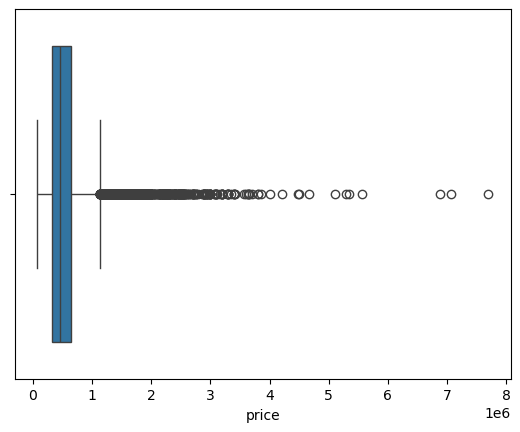

In [15]:
# Detect Outliers
import seaborn as sns

sns.boxplot(x=df["price"])

In [16]:
# Check Range of Features
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,21613.0,4.580302e+09,2.876566e+09,1.000102e+06,2.123049e+09,3.904930e+09,7.308900e+09,9.900000e+09
price,21613.0,5.400881e+05,3.671272e+05,7.500000e+04,3.219500e+05,4.500000e+05,6.450000e+05,7.700000e+06
bedrooms,21613.0,3.370842e+00,9.300618e-01,0.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,3.300000e+01
bathrooms,21613.0,2.114757e+00,7.701632e-01,0.000000e+00,1.750000e+00,2.250000e+00,2.500000e+00,8.000000e+00
sqft_living,21613.0,2.079900e+03,9.184409e+02,2.900000e+02,1.427000e+03,1.910000e+03,2.550000e+03,1.354000e+04
sqft_lot,21613.0,1.510697e+04,4.142051e+04,5.200000e+02,5.040000e+03,7.618000e+03,1.068800e+04,1.651359e+06
floors,21613.0,1.494309e+00,5.399889e-01,1.000000e+00,1.000000e+00,1.500000e+00,2.000000e+00,3.500000e+00
waterfront,21613.0,7.541757e-03,8.651720e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
view,21613.0,2.343034e-01,7.663176e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00
condition,21613.0,3.409430e+00,6.507430e-01,1.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00


In [17]:
# Remove Unnecessary Columns
df.drop("id", axis=1, inplace=True)

# Exploratory Data Analysis (EDA)

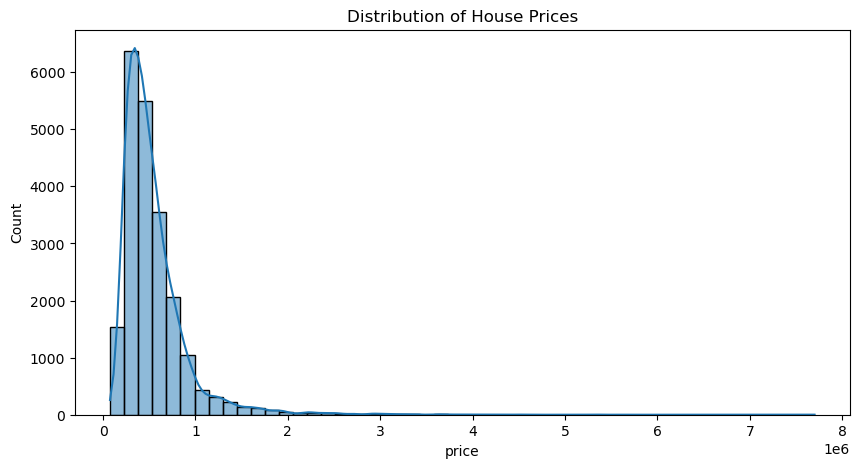

In [18]:
# Target Variable Analysis(Price)
plt.figure(figsize=(10,5))
sns.histplot(df["price"], bins=50, kde=True)
plt.title("Distribution of House Prices")
plt.show()

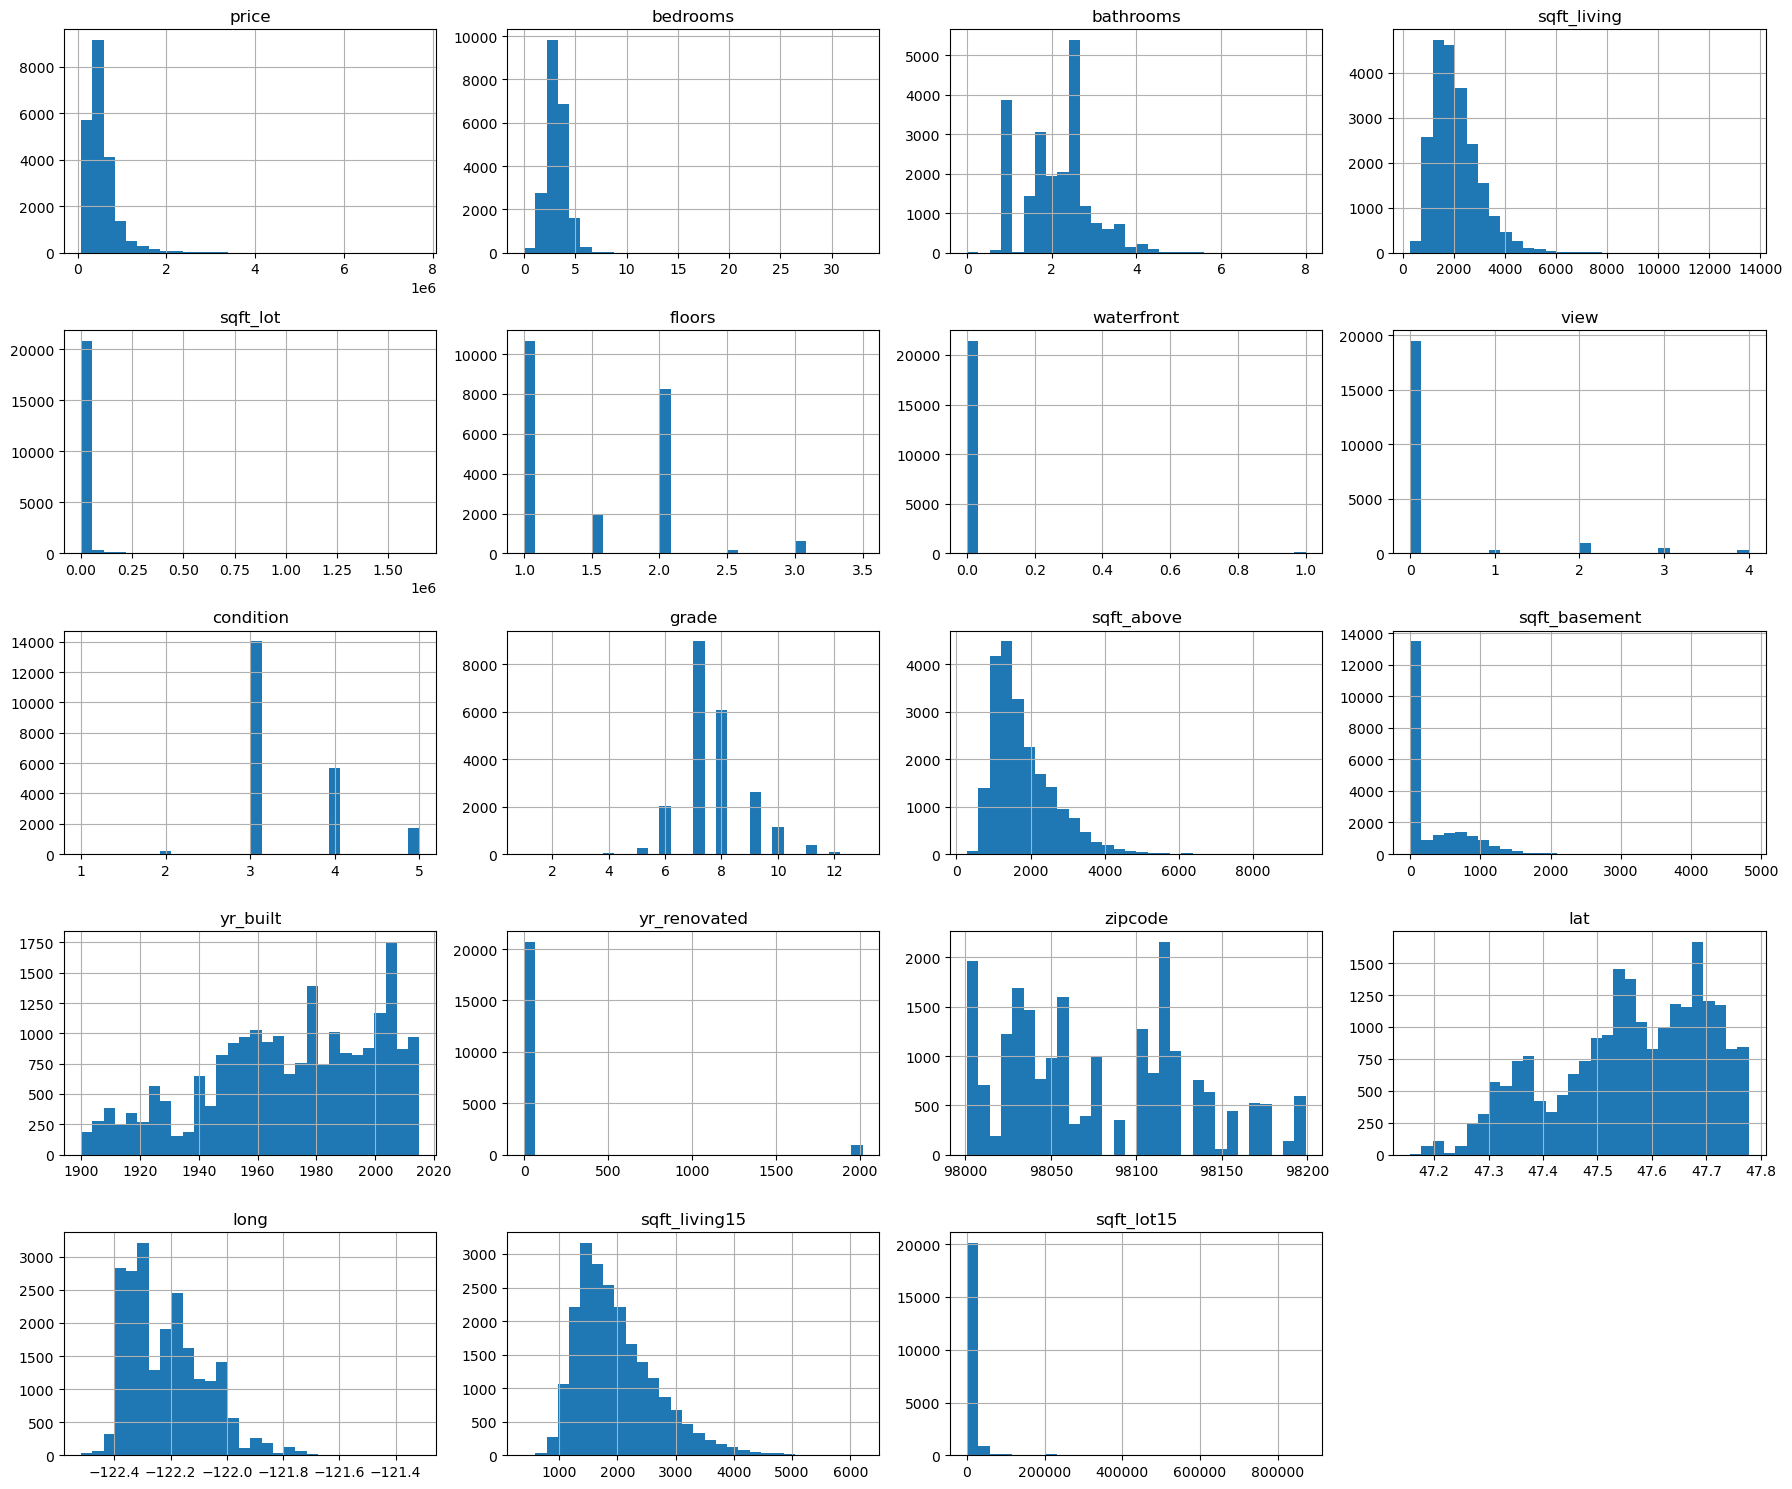

In [19]:
# Numerical Feature Distrbution
numerical_cols = df.select_dtypes(include=["int64","float64"]).columns

df[numerical_cols].hist(figsize=(18,15), bins=30)

plt.tight_layout()
plt.show()

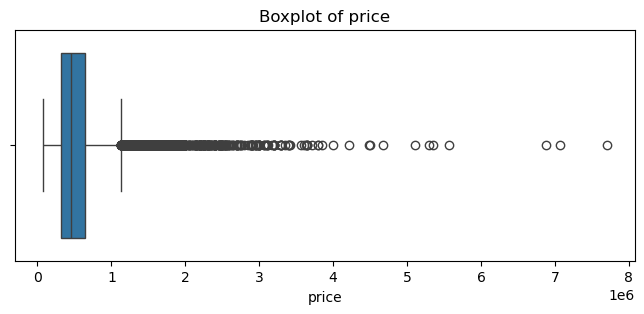

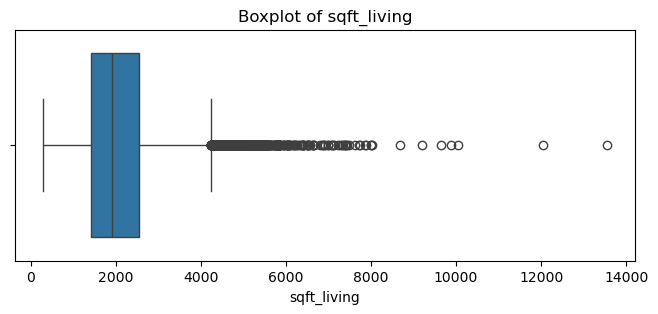

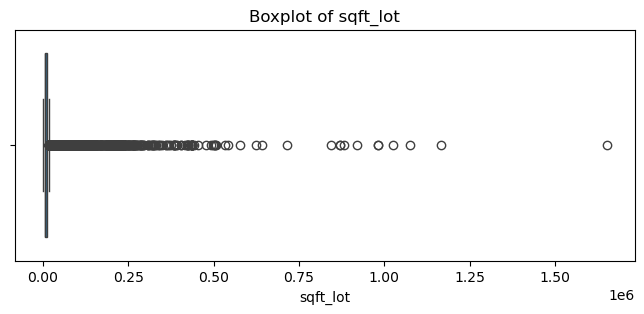

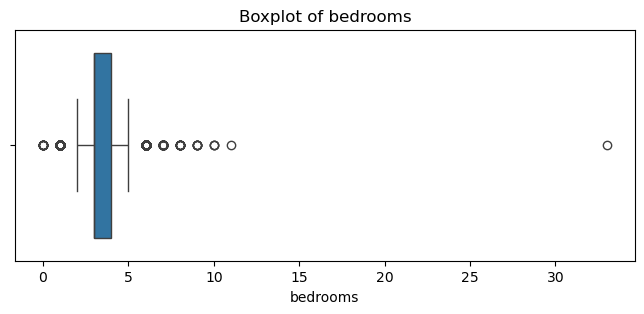

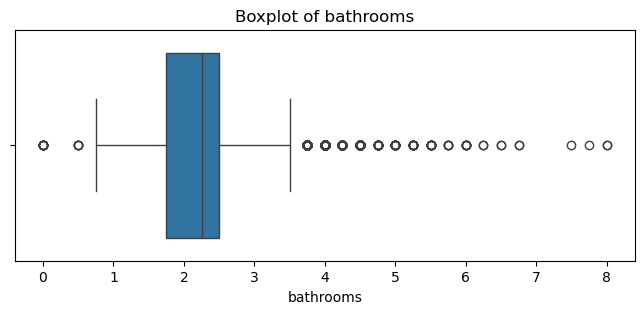

In [20]:
# Boxplots (Outlier Detection)
cols = ["price","sqft_living","sqft_lot","bedrooms","bathrooms"]

for col in cols:
    plt.figure(figsize=(8,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

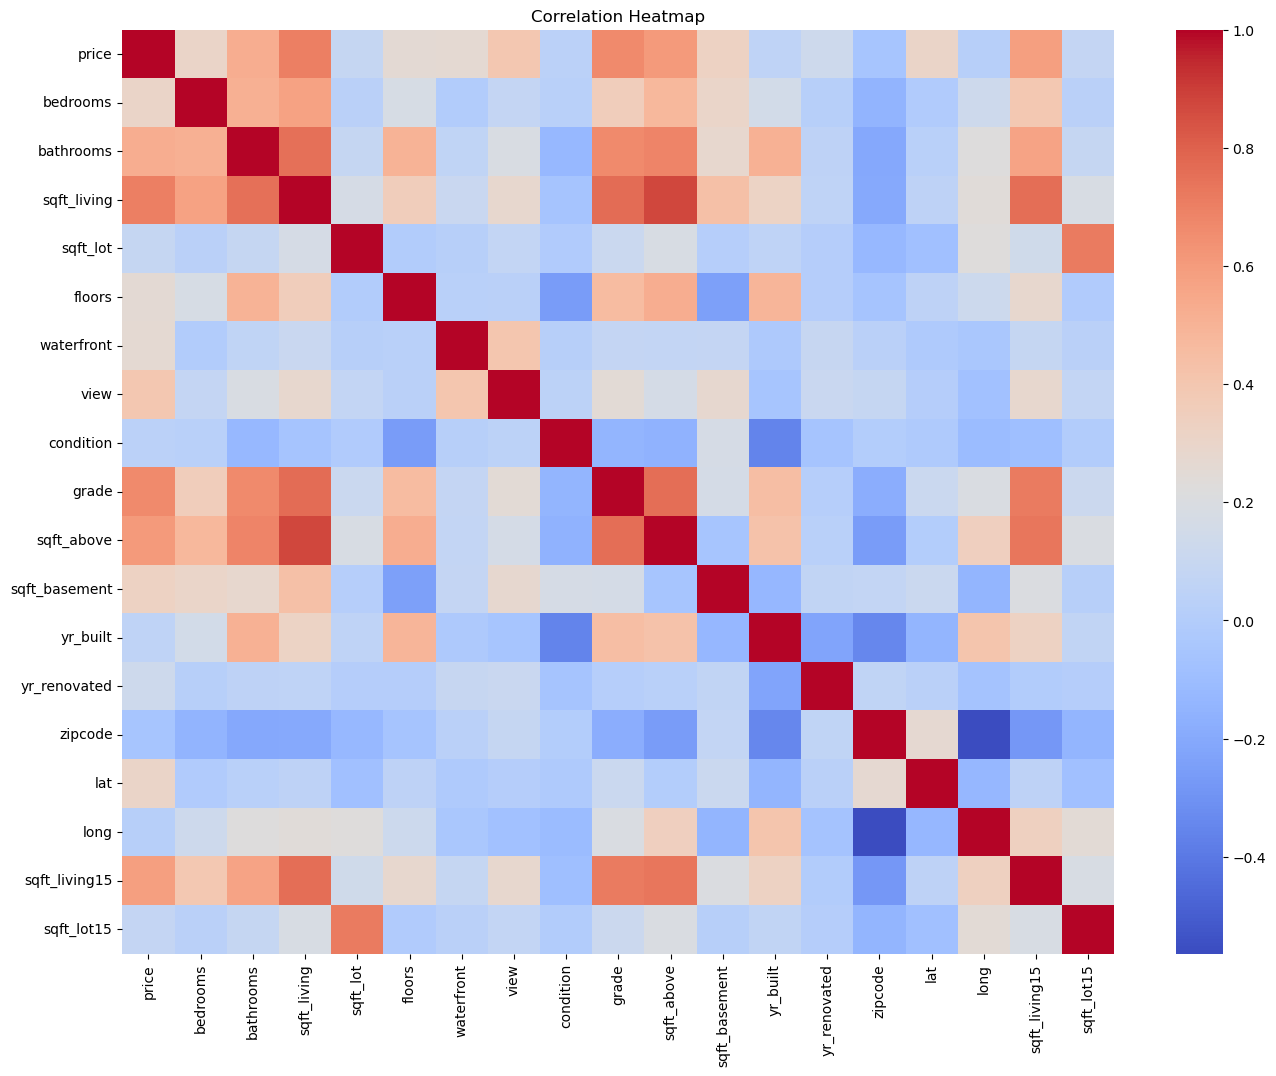

In [21]:
# Correlation Heatmap
plt.figure(figsize=(16,12))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")
plt.show()

In [22]:
# Top Correlation With Price
corr = df.corr(numeric_only=True)["price"].sort_values(ascending=False)

print(corr)

price            1.000000
sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585379
bathrooms        0.525138
view             0.397293
sqft_basement    0.323816
bedrooms         0.308350
lat              0.307003
waterfront       0.266369
floors           0.256794
yr_renovated     0.126434
sqft_lot         0.089661
sqft_lot15       0.082447
yr_built         0.054012
condition        0.036362
long             0.021626
zipcode         -0.053203
Name: price, dtype: float64


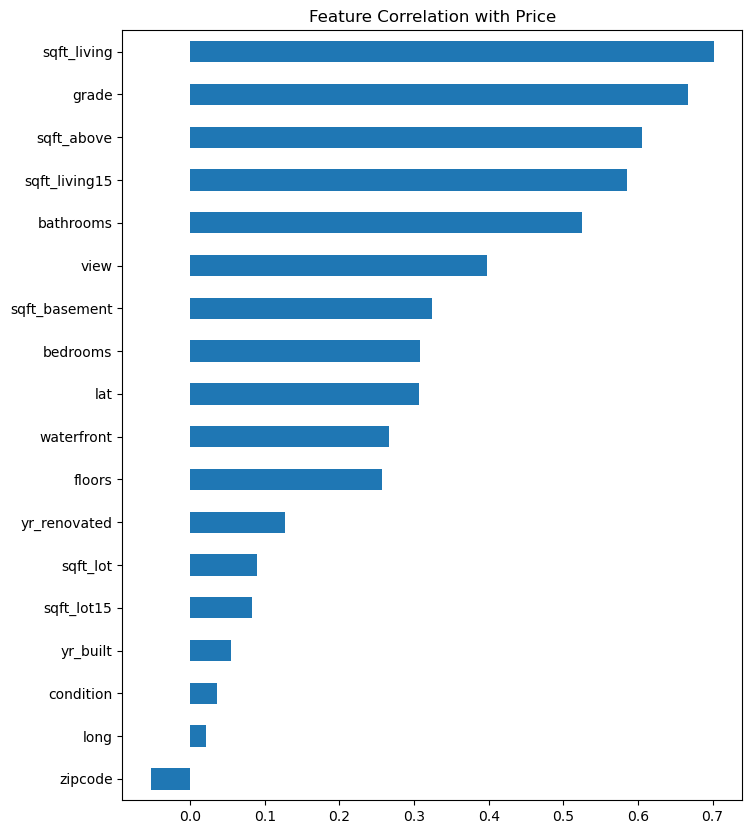

In [23]:
plt.figure(figsize=(8,10))

corr.drop("price").sort_values().plot(kind="barh")

plt.title("Feature Correlation with Price")

plt.show()

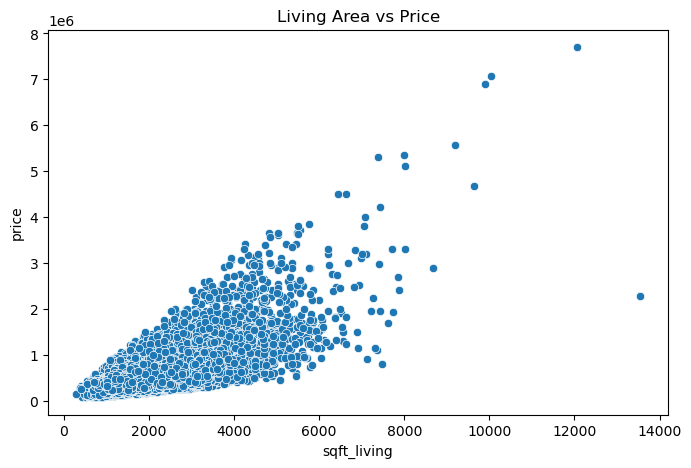

In [24]:
# Scatter Plot (Living Area vs Price)
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="sqft_living",
    y="price",
    data=df
)

plt.title("Living Area vs Price")

plt.show()

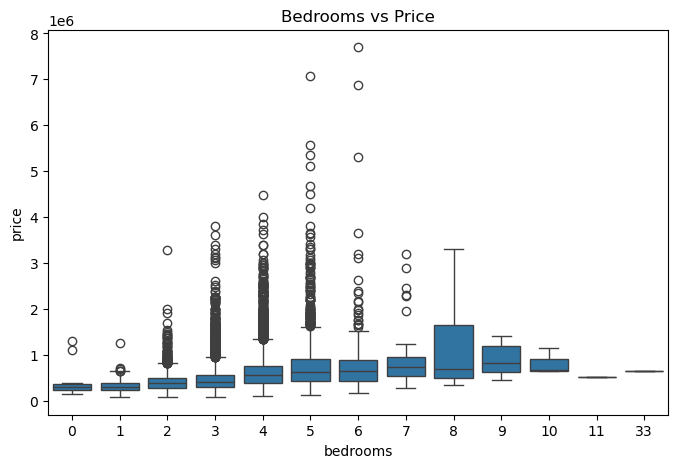

In [25]:
# Bedrooms vs Price
plt.figure(figsize=(8,5))

sns.boxplot(
    x="bedrooms",
    y="price",
    data=df
)

plt.title("Bedrooms vs Price")

plt.show()

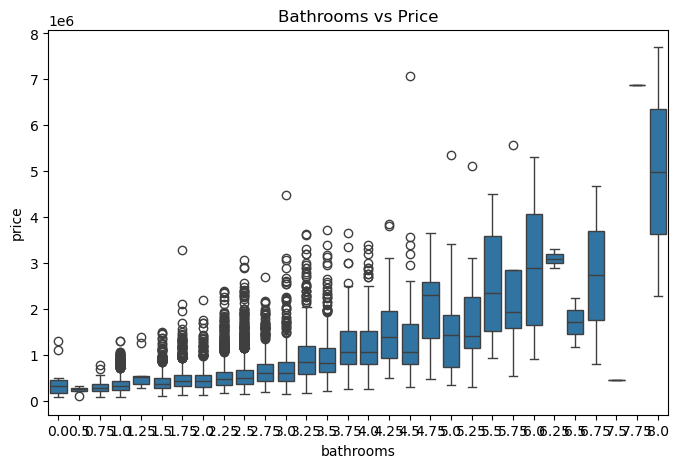

In [26]:
# Bathroom vs Price
plt.figure(figsize=(8,5))

sns.boxplot(
    x="bathrooms",
    y="price",
    data=df
)

plt.title("Bathrooms vs Price")

plt.show()

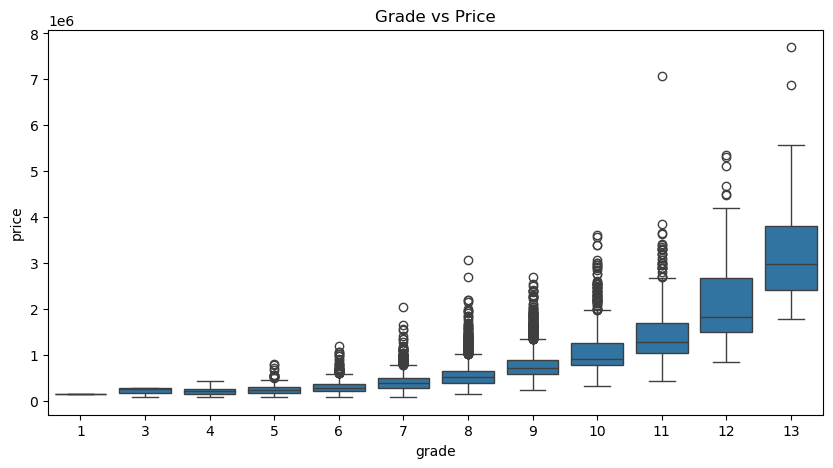

In [27]:
# Grade vs Price
plt.figure(figsize=(10,5))

sns.boxplot(
    x="grade",
    y="price",
    data=df
)

plt.title("Grade vs Price")

plt.show()

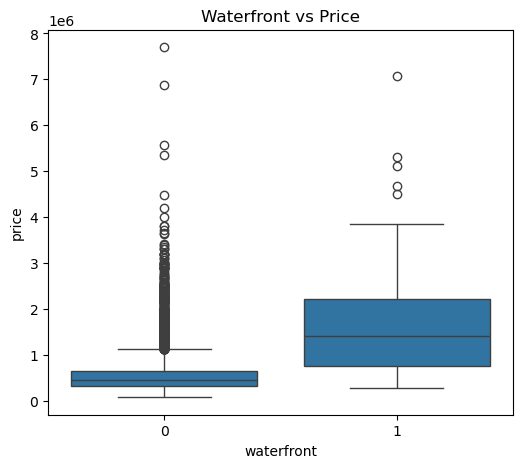

In [28]:
# Waterfront vs Price
plt.figure(figsize=(6,5))

sns.boxplot(
    x="waterfront",
    y="price",
    data=df
)

plt.title("Waterfront vs Price")

plt.show()

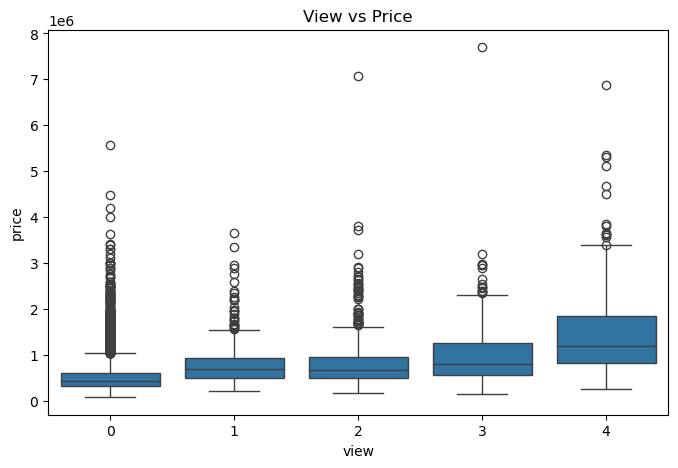

In [29]:
# Views vs Price
plt.figure(figsize=(8,5))

sns.boxplot(
    x="view",
    y="price",
    data=df
)

plt.title("View vs Price")

plt.show()

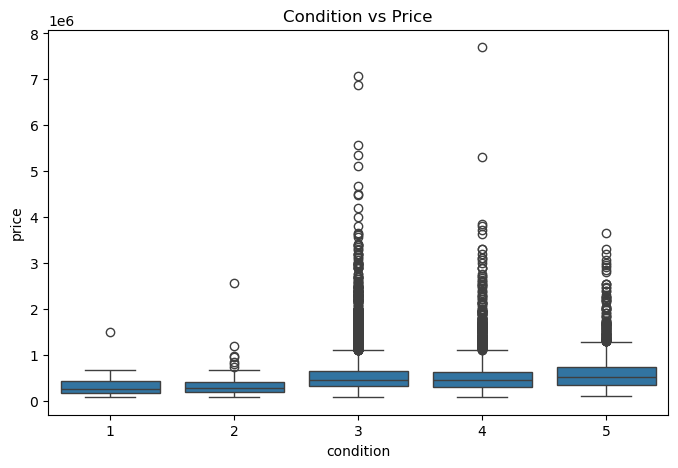

In [30]:
# Condition vs Price
plt.figure(figsize=(8,5))

sns.boxplot(
    x="condition",
    y="price",
    data=df
)

plt.title("Condition vs Price")

plt.show()

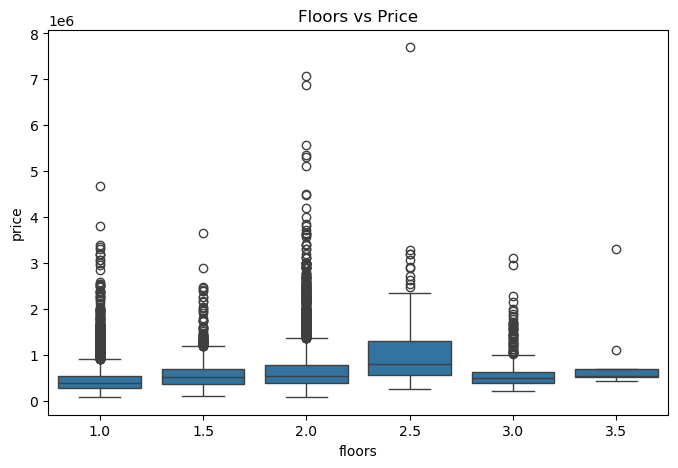

In [31]:
# Floors vs Price
plt.figure(figsize=(8,5))

sns.boxplot(
    x="floors",
    y="price",
    data=df
)

plt.title("Floors vs Price")

plt.show()

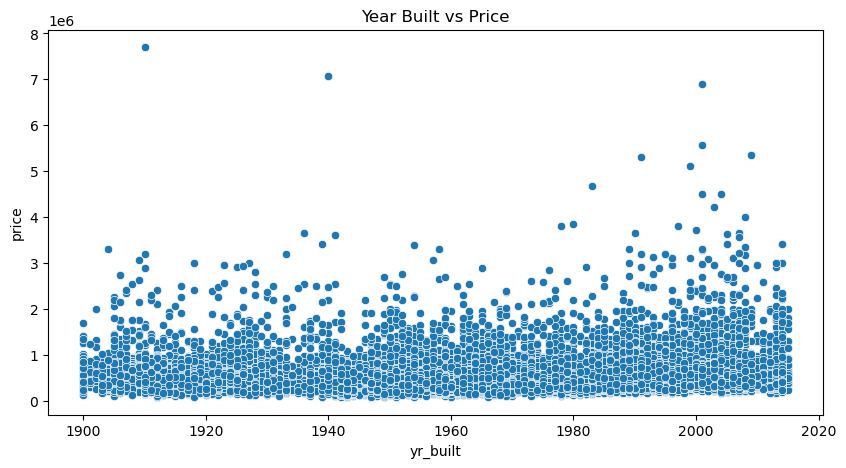

In [32]:
# Year Built Analysis
plt.figure(figsize=(10,5))

sns.scatterplot(
    x="yr_built",
    y="price",
    data=df
)

plt.title("Year Built vs Price")

plt.show()

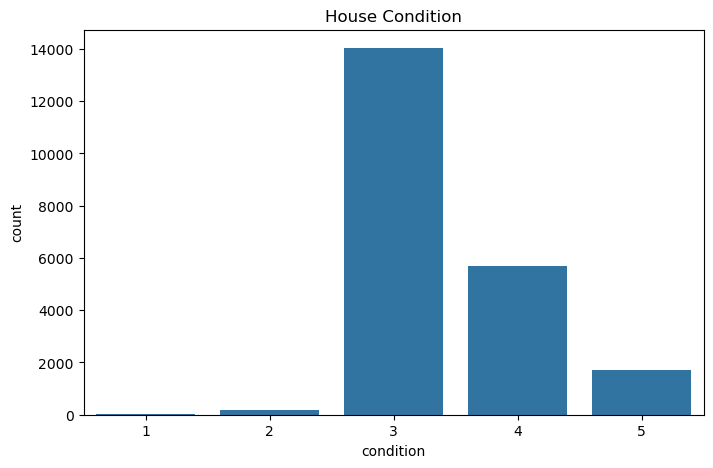

In [33]:
# Categorical Count Plots
plt.figure(figsize=(8,5))

sns.countplot(x="condition", data=df)

plt.title("House Condition")

plt.show()

# Feature Engineering

In [4]:
# Convert Date into Useful Features
df["date"] = pd.to_datetime(df["date"])

df["sale_year"] = df["date"].dt.year
df["sale_month"] = df["date"].dt.month

df.drop("date", axis=1, inplace=True)

In [5]:
# House Age
df["house_age"] = df["sale_year"] - df["yr_built"]

In [6]:
# Renovation Age
df["renovation_age"] = np.where(
    df["yr_renovated"] == 0,
    0,
    df["sale_year"] - df["yr_renovated"]
)

In [7]:
# Renovated or Not
df["is_renovated"] = (df["yr_renovated"] > 0).astype(int)

In [8]:
# Total Square Footage
df["total_sqft"] = df["sqft_above"] + df["sqft_basement"]

In [9]:
# Total Rooms
df["total_rooms"] = df["bedrooms"] + df["bathrooms"]

In [10]:
# Living Area Ratio
df["living_lot_ratio"] = df["sqft_living"] / df["sqft_lot"]

In [11]:
# Basement Availability
df["has_basement"] = (df["sqft_basement"] > 0).astype(int)

In [12]:
# Luxury House
df["luxury_house"] = (df["grade"] >= 10).astype(int)

In [13]:
# Large House
df["large_house"] = (df["sqft_living"] > 2500).astype(int)

In [14]:
# Price per Square Foot
df["price_per_sqft"] = df["price"] / df["sqft_living"]

In [15]:
df

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,house_age,renovation_age,is_renovated,total_sqft,total_rooms,living_lot_ratio,has_basement,luxury_house,large_house,price_per_sqft
0,7129300520,221900.0,3,1.00,1180,5650,1.0,0,0,3,...,59,0,0,1180,4.00,0.208850,0,0,0,188.050847
1,6414100192,538000.0,3,2.25,2570,7242,2.0,0,0,3,...,63,23,1,2570,5.25,0.354874,1,0,1,209.338521
2,5631500400,180000.0,2,1.00,770,10000,1.0,0,0,3,...,82,0,0,770,3.00,0.077000,0,0,0,233.766234
3,2487200875,604000.0,4,3.00,1960,5000,1.0,0,0,5,...,49,0,0,1960,7.00,0.392000,1,0,0,308.163265
4,1954400510,510000.0,3,2.00,1680,8080,1.0,0,0,3,...,28,0,0,1680,5.00,0.207921,0,0,0,303.571429
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,360000.0,3,2.50,1530,1131,3.0,0,0,3,...,5,0,0,1530,5.50,1.352785,0,0,0,235.294118
21609,6600060120,400000.0,4,2.50,2310,5813,2.0,0,0,3,...,1,0,0,2310,6.50,0.397385,0,0,0,173.160173
21610,1523300141,402101.0,2,0.75,1020,1350,2.0,0,0,3,...,5,0,0,1020,2.75,0.755556,0,0,0,394.216667
21611,291310100,400000.0,3,2.50,1600,2388,2.0,0,0,3,...,11,0,0,1600,5.50,0.670017,0,0,0,250.000000


# Data Preprocessing

In [16]:
# Separate Features and Target
X = df.drop("price", axis=1)
y = df["price"]

In [17]:
# Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [18]:
# StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [19]:
# Save the Scaler (useful for deployment)
import joblib

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [20]:
# Check Shapes
print(X_train.shape)
print(X_test.shape)

(17290, 31)
(4323, 31)


In [21]:
# Verify Scaling
print(f"Mean: {X_train_scaled.mean():.20f}")
print(f"Std: {X_train_scaled.std():.20f}")

Mean: -0.00000000000000172820
Std: 1.00000000000000000000


# Linear Regression

In [52]:
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [53]:
# Create the Model
lr = LinearRegression()

In [54]:
# Train the Model
lr.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [55]:
# Make PredictionS
y_pred = lr.predict(X_test_scaled)

In [56]:
# Evaluate the Model
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 68946.43464827143
MSE : 16791404138.388655
RMSE: 129581.6504694575
R² Score: 0.8889286326728733


In [57]:
import pandas as pd
# Display numbers in normal format
pd.options.display.float_format = '{:,.2f}'.format

# Display Actual vs Predicted
results = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

print(results.head(10))

       Actual Price  Predicted Price
735      365,000.00       375,145.87
2830     865,000.00       805,046.16
4106   1,038,000.00     1,128,662.82
16218  1,490,000.00     1,487,579.69
19964    711,000.00       639,213.64
1227     211,000.00       165,557.38
18849    790,000.00       725,181.26
19369    680,000.00       689,813.40
20164    384,500.00       366,976.93
7139     605,000.00       973,417.62


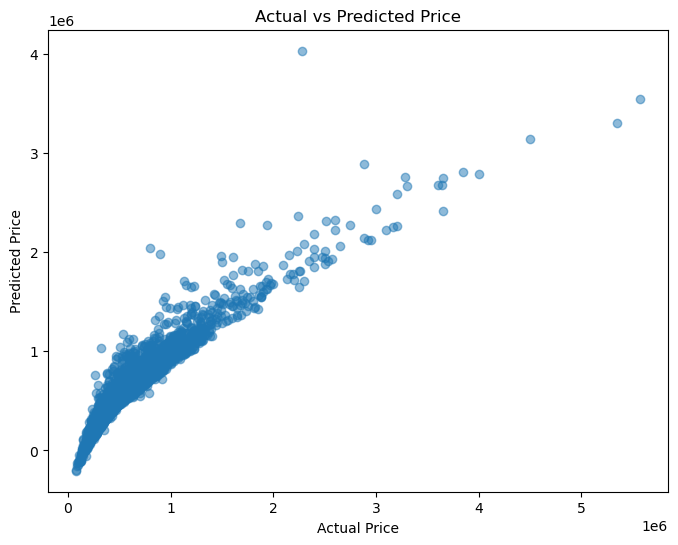

In [58]:
# actual vs predicted plot
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Price")

plt.show()

In [59]:
# Linear Regression Coefficients
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lr.coef_
})

print(coefficients.sort_values(by="Coefficient", ascending=False))

             Feature  Coefficient
12      yr_renovated   363,713.28
29    price_per_sqft   218,850.91
23        total_sqft    98,909.08
2        sqft_living    98,909.08
9         sqft_above    85,474.39
10     sqft_basement    44,474.11
27      luxury_house    21,758.15
5         waterfront    18,930.01
6               view    11,178.90
8              grade     9,997.00
1          bathrooms     7,479.29
7          condition     4,376.84
24       total_rooms     3,226.63
21    renovation_age     2,368.97
20         house_age     1,123.93
19        sale_month      -199.28
18         sale_year      -868.72
0           bedrooms    -1,029.12
26      has_basement    -1,073.63
11          yr_built    -1,137.79
25  living_lot_ratio    -1,287.85
15              long    -2,421.44
17        sqft_lot15    -3,477.28
14               lat    -5,306.13
3           sqft_lot    -5,817.73
13           zipcode    -6,518.39
4             floors    -6,745.20
16     sqft_living15   -16,958.35
28       large

# Gradient Boosting Regressor

In [60]:
# Gradient Boosting Regression
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gbr.fit(X_train, y_train)

gbr_pred = gbr.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 68946.43464827143
RMSE: 129581.6504694575
R2 Score: 0.8889286326728733


# Random Forest (Hyperparameter Tuning)

In [62]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

In [63]:
rf = RandomForestRegressor(random_state=42)

In [64]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

In [ ]:
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


In [77]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [78]:
best_rf = grid_search.best_estimator_

best_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsampl

In [80]:
y_pred_rf = best_rf.predict(X_test)

In [81]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2 = r2_score(y_test, y_pred_rf)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 32419.983145972223
RMSE: 79267.16655365516
R2 Score: 0.9584374894807257


# Xgboost

In [22]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [23]:
from xgboost import XGBRegressor

In [24]:
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

In [25]:
# Evaluation Metrics
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

mae = mean_absolute_error(y_test, xgb_pred)
rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
r2 = r2_score(y_test, xgb_pred)


print("XGBoost Model Performance")
print("-------------------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

XGBoost Model Performance
-------------------------
MAE : 8071.806671799098
RMSE: 37961.81266656459
R2 Score: 0.9904674522985866


# Lightgbm

In [26]:
pip install lightgbm

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [27]:
from lightgbm import LGBMRegressor

In [28]:
lgbm_model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

lgbm_model.fit(X_train, y_train)

lgbm_pred = lgbm_model.predict(X_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002297 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3598
[LightGBM] [Info] Number of data points in the train set: 17290, number of used features: 31
[LightGBM] [Info] Start training from score 537768.047947
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

In [29]:
mae = mean_absolute_error(y_test, lgbm_pred)
rmse = np.sqrt(mean_squared_error(y_test, lgbm_pred))
r2 = r2_score(y_test, lgbm_pred)


print("LGBMRegressor Model Performance")
print("-------------------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

LGBMRegressor Model Performance
-------------------------
MAE : 10492.078867043521
RMSE: 45859.4040611636
R2 Score: 0.9860885654314812


# Catboost

In [30]:
pip install catboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [31]:
from catboost import CatBoostRegressor

In [32]:
cat_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    random_state=42,
    verbose=0
)

cat_model.fit(X_train, y_train)

cat_pred = cat_model.predict(X_test) 

In [36]:
mae = mean_absolute_error(y_test, cat_pred)
rmse = np.sqrt(mean_squared_error(y_test, cat_pred))
r2 = r2_score(y_test, cat_pred)


print("CatBoostRegressor Model Performance")
print("-------------------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

CatBoostRegressor Model Performance
-------------------------
MAE : 7513.764987231516
RMSE: 23799.519916144367
R2 Score: 0.9962532777715355


In [33]:
# Select final model
best_model = cat_model

import pickle

# Save CatBoost model
with open("model.pkl", "wb") as file:
    pickle.dump(best_model, file)

# Save scaler if scaling was used
with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)